# 📘 **Simple Linear Regression using Gradient Descent (from Scratch)**

This notebook implements `simple linear regression` from scratch using Python and NumPy . 
We use **gradient descent** to optimize the parameters $ W , B $

---

## **Objective**

Given input feature `x-Hours`  and target `y-Score`, we want to learn a linear model:

$f_{w,b}(x) = wx + b$

That minimizes the **Mean Squared Error (MSE)** cost function:


$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2$


---

## **Load and prepare the Data**

In [506]:
#libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import math

In [507]:
df = pd.read_csv(r"E:\SALEH\Data\studentscores.csv") # data Reading

In [508]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [509]:
print("NULL" if df.isnull().values.any() else"NO Missing values")


NO Missing values


In [510]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


# **Model & Gradient descent** 

In [511]:
X_train = df.drop('Scores',axis=1).values.flatten() # feature

y_train = df['Scores']# Target

X_train.shape,y_train.shape

((25,), (25,))

---



$Linear\ Model:$  
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

$Cost\ Function:$  
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2 \tag{2}$$

 
- $w$ = weight (slope)  
- $b$ = bias (intercept)  
- $x^{(i)}$ = input of the $i^{th}$ training example  
- $y^{(i)}$ = true label of the $i^{th}$ example  
- $f_{w,b}(x^{(i)})$ = prediction  
- $m$ = number of training examples (X_train)


In [512]:
def cost_fun(x,y,w,b): # cost function
    
    m = x.shape[0] # Number of training samples
    
    cost = 0 # initialy

    for i in range(m):
        f_wb = w * x[i] + b # pridicted value (linear model )
        cost = cost + (f_wb - y[i])**2 # squared error 
    
    total_cost = 1/ (2*m)* cost
    
    

    return total_cost 

## **Implement Gradient Descent**

$Gradient\ (Derivatives):$  
$$\frac{\partial J(w, b)}{\partial w} = \frac{1}{m} \sum\limits_{i=0}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) \cdot x^{(i)} \tag{3}$$  
$$\frac{\partial J(w, b)}{\partial b} = \frac{1}{m} \sum\limits_{i=0}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) \tag{4}$$

$Update\ Rules:$  
$$w := w - \alpha \cdot \frac{\partial J(w, b)}{\partial w} \tag{5}$$  
$$b := b - \alpha \cdot \frac{\partial J(w, b)}{\partial b} \tag{6}$$

- $w$ = weight (slope)  
- $b$ = bias (intercept)  
- $\alpha$ = learning rate  
- $x^{(i)}$ = input of the $i^{th}$ training example  
- $y^{(i)}$ = true label of the $i^{th}$ example  
- $f_{w,b}(x^{(i)})$ = prediction  
- $m$ = number of training examples

In [513]:
def compute_gradient(x,y,w,b): # derivatives
    m = x.shape[0]
    
    dj_dw = 0
    dj_db = 0

    for i in range(m):   # loop for all training samples 
        
        f_wb = w * x[i] + b # model prediction for all samples
        
        dj_dw_i = (f_wb - y[i]) * x[i] # 3 
        
        dj_db_i = f_wb - y[i] # 4
        
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
        
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db







def compute_gradient2(x,y,w,b): # simpler version of derivatives calculations
    m = x.shape[0]
    dj_dw, dj_db = 0.0, 0.0
    for i in range(m):
        f_wb = w * x[i] + b
        error = f_wb - y[i]
        dj_dw += error * x[i]
        dj_db += error
    return dj_dw / m, dj_db / m


In [514]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, compute_gradient): 
    
    # An array to store cost J(cost fun) and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in
    
    for i in range(num_iters):
        # Calculate the gradient -> compute_gradient fun
        dj_dw, dj_db = compute_gradient(x, y, w , b)     

        # Update Parameters using equation (3) 
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # Save cost J at each iteration
        if i<100000:       
            J_history.append( cost_function(x, y, w , b))
            p_history.append([w,b])
            
        # Print cost every at intervals 10 times or as many iterations if < 10
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4}: Cost {round(J_history[-1], 4)} ",
          f"dj_dw: {round(dj_dw, 4)}, dj_db: {round(dj_db, 4)}  ",
          f"w: {round(w, 4)}, b: {round(b, 4)}")

 
    return w, b 

# **RUN**

In [515]:
w_init = 0 # initial w
b_init = 0 # initial b

iterations = 10000

alpha = 0.01  

# run gradient descent
w_final, b_final = gradient_descent(X_train ,y_train, w_init, b_init, alpha, iterations, cost_fun, compute_gradient)

Iteration    0: Cost 761.3462  dj_dw: -317.856, dj_db: -51.48   w: 3.1786, b: 0.5148
Iteration 1000: Cost 14.443  dj_dw: 0.004, dj_db: -0.0249   w: 9.7968, b: 2.3534
Iteration 2000: Cost 14.4414  dj_dw: 0.0006, dj_db: -0.0037   w: 9.7789, b: 2.4644
Iteration 3000: Cost 14.4414  dj_dw: 0.0001, dj_db: -0.0005   w: 9.7763, b: 2.4808
Iteration 4000: Cost 14.4414  dj_dw: 0.0, dj_db: -0.0001   w: 9.7759, b: 2.4833
Iteration 5000: Cost 14.4414  dj_dw: 0.0, dj_db: -0.0   w: 9.7758, b: 2.4836
Iteration 6000: Cost 14.4414  dj_dw: 0.0, dj_db: -0.0   w: 9.7758, b: 2.4837
Iteration 7000: Cost 14.4414  dj_dw: 0.0, dj_db: -0.0   w: 9.7758, b: 2.4837
Iteration 8000: Cost 14.4414  dj_dw: 0.0, dj_db: -0.0   w: 9.7758, b: 2.4837
Iteration 9000: Cost 14.4414  dj_dw: 0.0, dj_db: -0.0   w: 9.7758, b: 2.4837


In [520]:
print(f"(w,b)found by gradient descent: w = {w_final:.4f}, b = {b_final:.4f}")

(w,b)found by gradient descent: w = 9.7758, b = 2.4837


## **Visualization**

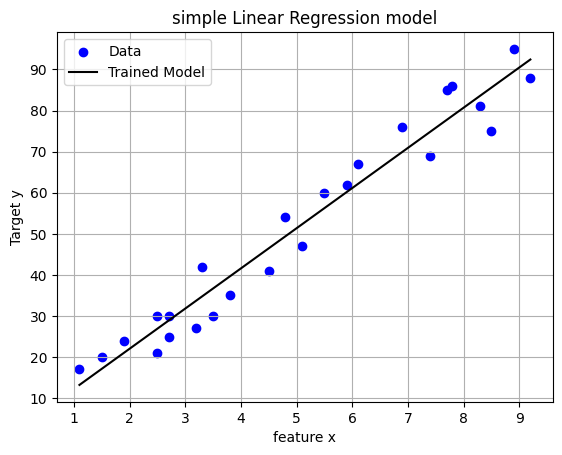

In [517]:
import matplotlib.pyplot as plt
import numpy as np


plt.scatter(X_train, y_train, label='Data', color='blue')

# Plot the model line
x_line = np.linspace(X_train.min(), X_train.max()) # gen values between Start and end
y_line = w_final * x_line + b_final # best param from gradient descent (W,B)
plt.plot(x_line, y_line, label='Trained Model', color='black')

plt.title("simple Linear Regression model")
plt.xlabel("feature x")
plt.ylabel("Target y")
plt.legend()
plt.grid()
plt.show()


# **Make prediction for new X**

In [521]:
x_new = 5
y_pred = w_final * x_new + b_final
print(f"Prediction for x={x_new} Hours : y={y_pred:.4f} Score")


Prediction for x=5 Hours : y=51.3627 Score
